# Fractal Renderer (Static)

- This code is sort of modular Taichi rendering of fractals.

- You can swap section 2 out (and tune the control panel params) for different fractals




As always, this has changed a lot.

### Iteration 1

We used the numpy approach to plot fractals using matplotlib.

This is cool and already pretty good, but what if we want to capture as much of the fratal detail for a given zoom level as possible?

### Iteration 2

We pick a huge image size > display resolution, compute the fractal in the same manner, and save the file. But this starts hitting some walls. 

1. Numpy uses ram and the CPU and if we do say 4x upsampling of 4k resolution we have an array of $3840 \times 2160 = 8,294,400 * 4 = 33,177,600$ pixels to compute. WE then pass this to the fractal formula which iterates up to `MAX_ITER` times. At this high of resolution we want accuracy so we might be doing 1,000 iterations $\rightarrow  33,177,600 \times 1,000 = 33,177,600,000$ individual calculations! 

It's worth noting that this only happens in areas that don't exceed the escape limit for our fractal, but what it translates to is a really slow render.

2. This slowness still ends up coming at the cost of accuracy! Each pixel actually contains infinite points on the complex plane. Remember that the fractal is continuous for all points. This means that there is a lot going on we're still not capturing.


> Insert the whole part about color depth, 1/sqrt loss, mathematic perfection, diminishing returns, and compute time.


### Iteration 3

We pass the computation of each point to the gpu which is way faster. But, our maximum resolution is >2^31 - 1 signed 32 bit integer dimensions 




### Iteration 4


The first cell now uses random sampling to compute pixels, and passes those back to memory. Each pixel is computed on the gpu using random sampling, passing that to the fractal equation, and then simple averaged. This is done `MAX_ITER` times per pixel and each iteration is tested in the `COMPUTE_PIXEL` function (fractal iteration) up to `MAX_ITER` times.


### Iteration 5

The second cell modifies that a bit to instead split the pixel into a grid of $\sqrt{SAMPLES\_PER\_PIXEL} \times \sqrt{SAMPLES\_PER\_PIXEL}$, and computes the fractal color for each of those points, up to `MAX_ITER` times.

We could simple average those, but instead here's the big insight. **The fractal is chaotic**. This means that the arithmetic mean $\frac{\sum_{0}^{SAMPLES} MAX\_ITER}{SAMPLES}$ is not necessarily representative of the true average color. The system being chaotic means that the distribution of colors over the pixel is not necessarily normal $~(\mu,\sigma ^2)$. Even when using the grid approach, the fractal is still recursive and we end up with the same potential issue within each of those grids. Accuracy here is capped by the color depth of the display. Each pixel has 32 bit precision (10 million discrete values) on $ [0,1] $ in 10 bit color. At 4k, this means as above, computing the smallest possible color step $\frac$$\frac{1}{\sqrt{N}} $

However, to address this a little bit without needing to com

# Colormaps

1. Arches
2. qPBI
3. skull_77
4. Bmpoop
5. Takahe

[Taichi] Starting on arch=vulkan
Allocating VRAM for 15360x4320...
Rendering 16 stratified Gaussian samples per pixel...
Transferring data to RAM...


Data range: min=nan, max=nan, mean=nan
Generating inline preview...
Display range: 9.0426 to 134.5446


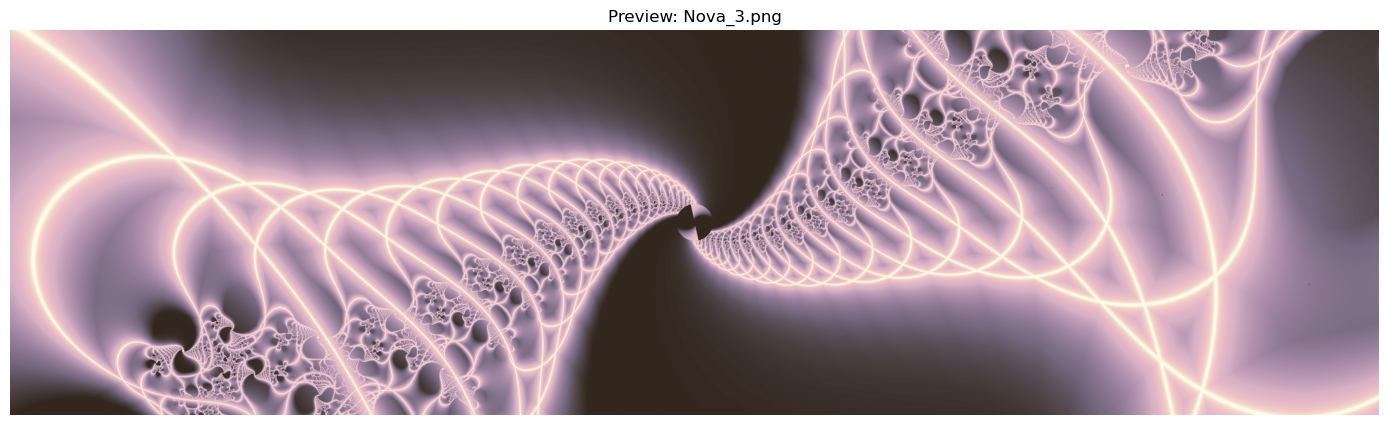

Writing high-res output to disk...
Done! Saved as Nova_3.png


In [79]:
# Newton / Nova_2 — improved coloring


import taichi as ti
from math import pi
import numpy as np
import matplotlib.pyplot as plt
import cmasher as cmr
from pypalettes import load_cmap



# Automatically grabs your GPU
ti.init(arch=ti.gpu)

# =========================================================================
# 1. THE CONTROL PANEL (Global Settings)
# =========================================================================
# 4cx file size 
WIDTH, HEIGHT = 5120*3, 1440*3

# --- THE MAGIC DIAL ---

# We use a grid size now. 8x8 = 64 samples, 16x16 = 256 samples, etc.
GRID_SIZE = 4
# Sigma controls the "blur" of the Gaussian curve. 0.5 is a great standard.
SIGMA = 0.5

ZOOM = 10

CENTER_X, CENTER_Y = 0, 0

MAX_ITER = 2500
ESCAPE_RADIUS = 500

COLORMAP =  load_cmap("Shuksan", cmap_type="continuous", reverse = True)# Swapped to a default matplotlib map just in case cmasher isn't loaded
FILENAME = 'Nova_3.png'

# --- Coloring weights — tweak these to taste ---
W_SMOOTH = 25.0      # smooth iteration count contribution
W_ANGLE  = 180.0      # which-root / basin-angle contribution (breaks the circle)
W_TRAP   = 25.0      # log(min_dist-to-unit-circle) contribution — Nova_2 uses unit-circle trap
W_GRAZE = 45.0  # Optional: adds a grazing angle term to highlight near-misses (not used in Nova_2)

# =========================================================================
# 2. THE NEWTON FRACTAL MODULE (f(z) = z^3 - 1)
# =========================================================================
@ti.func
def compute_pixel(x: float, y: float) -> float:
    z = ti.Vector([x, y])
    
    c = ti.Vector([-0.45, 0.6])
    a_re, a_im = 0.99, 0.45
    
    local_max_iter = 500
    tolerance = 1e-5
    min_dist = 1e10
    
    # Track final step magnitude for smooth iteration count
    final_step_sq = 1.0
    
    iter_count = 0
    converged = False
    while iter_count < local_max_iter:
        z2_x = z[0]**2 - z[1]**2
        z2_y = 2.0 * z[0] * z[1]
        z3_x = z2_x * z[0] - z2_y * z[1]
        z3_y = z2_x * z[1] + z2_y * z[0]
        
        fz_x = z3_x - 1.0
        fz_y = z3_y
        dfz_x = 3.0 * z2_x
        dfz_y = 3.0 * z2_y
        
        den = dfz_x**2 + dfz_y**2
        if den < 1e-10:
            break
        
        step_x = (fz_x * dfz_x + fz_y * dfz_y) / den
        step_y = (fz_y * dfz_x - fz_x * dfz_y) / den
        
        az_x = a_re * step_x - a_im * step_y
        az_y = a_re * step_y + a_im * step_x
        z[0] -= az_x
        z[1] -= az_y
        z[0] += c[0]
        z[1] += c[1]
        
        # Track closest approach to the UNIT CIRCLE, not the origin
        r = ti.sqrt(z[0]**2 + z[1]**2)
        dist = ti.abs(r - 1.5)
        if dist < min_dist:
            min_dist = dist
        
        # Remember the step size — used for smoothing on convergence
        final_step_sq = step_x**2 + step_y**2
        
        if z[0]**2 + z[1]**2 > 1e6:
            break
        
        if final_step_sq < tolerance:
            converged = True
            break
        iter_count += 1
    
    # --- Smooth (fractional) iteration count ---
    # Replaces integer iter_count with a continuous value — kills the banding.
    smooth = float(iter_count)
    if final_step_sq > 1e-30:
        smooth = float(iter_count) - ti.log(ti.log(final_step_sq) + 20.0) / ti.log(2.0)
    
    # --- Basin angle: which root did we land on? ---
    # The big trick. For z^3 - 1 there are 3 roots; this gives each basin
    # its own color band so the central disk stops collapsing to one value.
    final_angle = ti.atan2(z[1], z[0]) / (2.0 * pi) + 0.5
    
    # --- Combine three independent signals ---
    color_val = (
        W_SMOOTH * smooth
        + W_ANGLE * final_angle
        + W_TRAP  * ti.log(min_dist + 1e-10)
    )
    
    # Non-converged points: lean on the trap + angle so they blend smoothly.
    if not converged and iter_count >= local_max_iter:
        color_val = W_TRAP * ti.log(min_dist + 1e-10) + W_ANGLE * final_angle
    
    return color_val


# =========================================================================
# 3. THE RENDER ENGINE (Stratified & Gaussian)
# =========================================================================
pixels = ti.field(dtype=ti.f32, shape=(WIDTH, HEIGHT))



@ti.kernel
def render_kernel():
    aspect_ratio = float(WIDTH) / float(HEIGHT)
    y_view = 2.0 / ZOOM
    x_view = y_view * aspect_ratio

    for i, j in pixels:
        total_color = 0.0
        total_weight = 0.0
        
        # --- 1. Stratified Grid Loop ---
        for sx in range(GRID_SIZE):
            for sy in range(GRID_SIZE):
                
                # Create a random jitter strictly within this specific sub-grid box
                jitter_x = (float(sx) + ti.random(dtype=ti.f32)) / float(GRID_SIZE)
                jitter_y = (float(sy) + ti.random(dtype=ti.f32)) / float(GRID_SIZE)
                
                # Calculate distance from the exact center of the pixel (0.5, 0.5)
                dx = jitter_x - 0.5
                dy = jitter_y - 0.5
                
                # --- 2. Gaussian Weight ---
                # Samples near the center get high weight, edges drop off exponentially
                weight = ti.exp(-(dx**2 + dy**2) / (2.0 * SIGMA**2))
                
                # Map to complex plane
                x0 = ((float(i) + jitter_x) / float(WIDTH)) * 2.0 * x_view - x_view + CENTER_X
                y0 = ((float(j) + jitter_y) / float(HEIGHT)) * 2.0 * y_view - y_view + CENTER_Y
                
                # Calculate fractal math and multiply by our statistical weight
                color_val = compute_pixel(x0, y0)
                total_color += color_val * weight
                total_weight += weight
                
        # Divide by the sum of the weights to normalize the final color
        pixels[i, j] = total_color / total_weight

def main():
    print(f"Allocating VRAM for {WIDTH}x{HEIGHT}...")
    total_samples = GRID_SIZE * GRID_SIZE 
    print(f"Rendering {total_samples} stratified Gaussian samples per pixel...")
    
    # Run the Taichi kernel on the GPU
    render_kernel()
    
    # 1. Pull the data from VRAM to system memory (RAM)
    print("Transferring data to RAM...")
    data = np.transpose(pixels.to_numpy())
    print(f"Data range: min={data.min():.4f}, max={data.max():.4f}, mean={data.mean():.4f}")
    
    # 2. Generate inline preview
    print("Generating inline preview...")
    # Adjust the step size (e.g., ::4) if your preview is still too large/slow
    preview_data = data[::4, ::4] 
    
    aspect = WIDTH / HEIGHT
    fig_height = 5
    fig_width = fig_height * aspect
    
    plt.figure(figsize=(fig_width, fig_height))
    vmin = np.percentile(preview_data, 2)
    vmax = np.percentile(preview_data, 98)
    print(f"Display range: {vmin:.4f} to {vmax:.4f}")
    plt.imshow(preview_data, cmap=COLORMAP, origin='lower', vmin=vmin, vmax=vmax)
    plt.axis('off') 
    plt.title(f"Preview: {FILENAME}")
    plt.show()

    # 3. Provide the option to save
    # In Jupyter, this will create a little text box below the cell
    choice = input(f"Would you like to save this render as '{FILENAME}'? (y/n): ").strip().lower()
    
    if choice == 'y':
        print("Writing high-res output to disk...")
        
        # Scrub any NaN/inf values — these become transparent pixels otherwise
        clean_data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
        
        vmin = np.percentile(clean_data, 2)
        vmax = np.percentile(clean_data, 98)
        
        # Guard against vmin == vmax (would divide by zero)
        if vmax - vmin < 1e-10:
            vmax = vmin + 1.0
        
        normalized = np.clip((clean_data - vmin) / (vmax - vmin), 0.0, 1.0)
        plt.imsave(FILENAME, normalized, cmap=COLORMAP, origin='lower')
        print(f"Done! Saved as {FILENAME}")
    else:
        print("Render kept in memory but not saved to disk.")
        
    # 4. Return the data so it stays in memory for other notebook cells
    return data

if __name__ == '__main__':
    # By assigning it to a variable, the data stays in RAM!
    # You can now access 'fractal_data' in the next Jupyter cell.
    fractal_data = main()

In [34]:
# Newton / Nova_2 — animated version
# Orbits (a_re, a_im) around the unit circle with eased timing for smooth looping.


import taichi as ti
from math import pi
import numpy as np
import matplotlib.pyplot as plt
import cmasher as cmr
from pypalettes import load_cmap
from pathlib import Path



# Automatically grabs your GPU
ti.init(arch=ti.gpu)

# =========================================================================
# 1. THE CONTROL PANEL (Global Settings)
# =========================================================================
# Reduced for animation — single frame at full res took too long
WIDTH, HEIGHT = 5120, 1440

# --- THE MAGIC DIAL ---
# Grid size of 1 = no supersampling (one sample per pixel). Fast for animation.
GRID_SIZE = 1
SIGMA = 0.5

ZOOM = 7.5

CENTER_X, CENTER_Y = 0, 0

MAX_ITER = 2500
ESCAPE_RADIUS = 500

COLORMAP = load_cmap("Bmpoop", cmap_type="continuous", reverse=False)

# --- Animation settings ---
NUM_FRAMES = 240               # 10 seconds at 24fps
OUTPUT_DIR = Path("frames")    # Where individual PNGs land
FRAME_PREFIX = "nova2"         # frame_nova2_00000.png, etc.

# --- Coloring weights ---
W_SMOOTH = 25.0
W_ANGLE  = 180.0
W_TRAP   = 25.0
W_GRAZE  = 45.0  # not used here but kept for parity

# =========================================================================
# 2. THE NEWTON FRACTAL MODULE (f(z) = z^3 - 1)
# =========================================================================
@ti.func
def compute_pixel(x: float, y: float, a_re: float, a_im: float) -> float:
    z = ti.Vector([x, y])
    
    c = ti.Vector([-0.45, 0.6])
    # a_re, a_im now arrive as parameters from the kernel call
    
    local_max_iter = 500
    tolerance = 1e-5
    min_dist = 1e10
    
    final_step_sq = 1.0
    
    iter_count = 0
    converged = False
    while iter_count < local_max_iter:
        z2_x = z[0]**2 - z[1]**2
        z2_y = 2.0 * z[0] * z[1]
        z3_x = z2_x * z[0] - z2_y * z[1]
        z3_y = z2_x * z[1] + z2_y * z[0]
        
        fz_x = z3_x - 1.0
        fz_y = z3_y
        dfz_x = 3.0 * z2_x
        dfz_y = 3.0 * z2_y
        
        den = dfz_x**2 + dfz_y**2
        if den < 1e-10:
            break
        
        step_x = (fz_x * dfz_x + fz_y * dfz_y) / den
        step_y = (fz_y * dfz_x - fz_x * dfz_y) / den
        
        az_x = a_re * step_x - a_im * step_y
        az_y = a_re * step_y + a_im * step_x
        z[0] -= az_x
        z[1] -= az_y
        z[0] += c[0]
        z[1] += c[1]
        
        # Distance to circle of radius 1.5 (matches your latest experiment)
        r = ti.sqrt(z[0]**2 + z[1]**2)
        dist = ti.abs(r - 1.5)
        if dist < min_dist:
            min_dist = dist
        
        final_step_sq = step_x**2 + step_y**2
        
        if z[0]**2 + z[1]**2 > 1e6:
            break
        
        if final_step_sq < tolerance:
            converged = True
            break
        iter_count += 1
    
    smooth = float(iter_count)
    if final_step_sq > 1e-30:
        smooth = float(iter_count) - ti.log(ti.log(final_step_sq) + 20.0) / ti.log(2.0)
    
    final_angle = ti.atan2(z[1], z[0]) / (2.0 * pi) + 0.5
    
    color_val = (
        W_SMOOTH * smooth
        + W_ANGLE * final_angle
        + W_TRAP  * ti.log(min_dist + 1e-10)
    )
    
    if not converged and iter_count >= local_max_iter:
        color_val = W_TRAP * ti.log(min_dist + 1e-10) + W_ANGLE * final_angle
    
    return color_val


# =========================================================================
# 3. THE RENDER ENGINE — kernel now takes a_re, a_im as arguments
# =========================================================================
pixels = ti.field(dtype=ti.f32, shape=(WIDTH, HEIGHT))


@ti.kernel
def render_kernel(a_re: ti.f32, a_im: ti.f32):
    aspect_ratio = float(WIDTH) / float(HEIGHT)
    y_view = 2.0 / ZOOM
    x_view = y_view * aspect_ratio

    for i, j in pixels:
        total_color = 0.0
        total_weight = 0.0
        
        for sx in range(GRID_SIZE):
            for sy in range(GRID_SIZE):
                jitter_x = (float(sx) + ti.random(dtype=ti.f32)) / float(GRID_SIZE)
                jitter_y = (float(sy) + ti.random(dtype=ti.f32)) / float(GRID_SIZE)
                
                dx = jitter_x - 0.5
                dy = jitter_y - 0.5
                
                weight = ti.exp(-(dx**2 + dy**2) / (2.0 * SIGMA**2))
                
                x0 = ((float(i) + jitter_x) / float(WIDTH)) * 2.0 * x_view - x_view + CENTER_X
                y0 = ((float(j) + jitter_y) / float(HEIGHT)) * 2.0 * y_view - y_view + CENTER_Y
                
                color_val = compute_pixel(x0, y0, a_re, a_im)
                total_color += color_val * weight
                total_weight += weight
                
        pixels[i, j] = total_color / total_weight


# =========================================================================
# 4. ANIMATION PATH
# =========================================================================
def smoothstep(t: float) -> float:
    """Cubic ease in-out. Maps [0,1] -> [0,1] with zero derivative at endpoints."""
    return t * t * (3.0 - 2.0 * t)

def animation_path(frame_idx: int, total_frames: int):
    """
    Orbit (a_re, a_im) around the unit circle.
    
    Because the path is already periodic (a full circle), we DON'T ease
    the angle itself — that would slow the loop near the start/end and
    actually break the smoothness. Instead we use raw linear t for angular
    motion. The 'easing' for a closed loop is automatic: the orbit has
    constant angular velocity, which is what you want for a hypnotic loop.
    
    If you want eased non-looping motion (e.g. spiral, sweep, zoom) the
    easing line below is where you'd plug it in.
    """
    t = frame_idx / total_frames   # 0 to (just under) 1, never reaches 1
    
    # Orbit the unit circle: (cos(angle), sin(angle))
    angle = 2.0 * pi * t
    a_re = float(np.cos(angle))
    a_im = float(np.sin(angle))
    
    return a_re, a_im


# =========================================================================
# 5. RENDER LOOP
# =========================================================================
def render_one_frame(a_re: float, a_im: float) -> np.ndarray:
    render_kernel(a_re, a_im)
    data = np.transpose(pixels.to_numpy())
    return np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)


def animate():
    OUTPUT_DIR.mkdir(exist_ok=True)
    
    print(f"Output: {OUTPUT_DIR.resolve()}")
    print(f"Resolution: {WIDTH}x{HEIGHT}, GRID_SIZE={GRID_SIZE}")
    print(f"Frames: {NUM_FRAMES}\n")
    
    # ---------------------------------------------------------------
    # Step 1: Compute global vmin/vmax from a reference frame.
    # CRITICAL: per-frame percentiles cause flicker/breathing.
    # We pick a midpoint frame as the reference. If your animation
    # has wildly different frames (e.g. some all-disk, some all-fractal)
    # you may want to sample a few frames and average the percentiles.
    # ---------------------------------------------------------------
    print("Computing reference normalization from midpoint frame...")
    ref_a_re, ref_a_im = animation_path(NUM_FRAMES // 2, NUM_FRAMES)
    print(f"  Reference a = ({ref_a_re:.4f}, {ref_a_im:.4f})")
    ref_data = render_one_frame(ref_a_re, ref_a_im)
    
    GLOBAL_VMIN = float(np.percentile(ref_data, 2))
    GLOBAL_VMAX = float(np.percentile(ref_data, 98))
    if GLOBAL_VMAX - GLOBAL_VMIN < 1e-10:
        GLOBAL_VMAX = GLOBAL_VMIN + 1.0
    print(f"  Locked vmin={GLOBAL_VMIN:.4f}, vmax={GLOBAL_VMAX:.4f}\n")
    
    # ---------------------------------------------------------------
    # Step 2: Render every frame using the locked normalization.
    # ---------------------------------------------------------------
    import time
    start_time = time.time()
    
    for frame in range(NUM_FRAMES):
        a_re, a_im = animation_path(frame, NUM_FRAMES)
        data = render_one_frame(a_re, a_im)
        
        normalized = np.clip(
            (data - GLOBAL_VMIN) / (GLOBAL_VMAX - GLOBAL_VMIN),
            0.0, 1.0
        )
        
        filename = OUTPUT_DIR / f"{FRAME_PREFIX}_{frame:05d}.png"
        plt.imsave(str(filename), normalized, cmap=COLORMAP, origin='lower')
        
        elapsed = time.time() - start_time
        avg_per_frame = elapsed / (frame + 1)
        eta = avg_per_frame * (NUM_FRAMES - frame - 1)
        print(f"Frame {frame+1:4d}/{NUM_FRAMES}  "
              f"a=({a_re:+.3f}, {a_im:+.3f})  "
              f"elapsed={elapsed:6.1f}s  "
              f"eta={eta:6.1f}s")
    
    total = time.time() - start_time
    print(f"\nDone in {total:.1f}s. Frames saved to {OUTPUT_DIR.resolve()}")
    print(f"\nTo make the video, run:")
    print(f"  ffmpeg -framerate 24 -i {OUTPUT_DIR}/{FRAME_PREFIX}_%05d.png \\")
    print(f"         -c:v libx264 -pix_fmt yuv420p -crf 18 \\")
    print(f"         -vf 'scale=trunc(iw/2)*2:trunc(ih/2)*2' \\")
    print(f"         {FRAME_PREFIX}_orbit.mp4")


if __name__ == '__main__':
    animate()

[Taichi] Starting on arch=vulkan
Output: /mnt/hard_storage/GithubRepos/project-dev/Ad_Hoc/Personal/Fractals/frames
Resolution: 5120x1440, GRID_SIZE=1
Frames: 240

Computing reference normalization from midpoint frame...
  Reference a = (-1.0000, 0.0000)
  Locked vmin=295.6176, vmax=557.1610



Frame    1/240  a=(+1.000, +0.000)  elapsed=   0.2s  eta=  47.7s
Frame    2/240  a=(+1.000, +0.026)  elapsed=   0.4s  eta=  42.1s
Frame    3/240  a=(+0.999, +0.052)  elapsed=   0.5s  eta=  40.5s
Frame    4/240  a=(+0.997, +0.078)  elapsed=   0.7s  eta=  39.5s
Frame    5/240  a=(+0.995, +0.105)  elapsed=   0.8s  eta=  38.8s
Frame    6/240  a=(+0.991, +0.131)  elapsed=   1.0s  eta=  38.3s
Frame    7/240  a=(+0.988, +0.156)  elapsed=   1.1s  eta=  37.9s
Frame    8/240  a=(+0.983, +0.182)  elapsed=   1.3s  eta=  37.4s
Frame    9/240  a=(+0.978, +0.208)  elapsed=   1.4s  eta=  37.1s
Frame   10/240  a=(+0.972, +0.233)  elapsed=   1.6s  eta=  37.2s
Frame   11/240  a=(+0.966, +0.259)  elapsed=   1.8s  eta=  36.9s
Frame   12/240  a=(+0.959, +0.284)  elapsed=   1.9s  eta=  36.7s
Frame   13/240  a=(+0.951, +0.309)  elapsed=   2.1s  eta=  36.4s
Frame   14/240  a=(+0.943, +0.334)  elapsed=   2.2s  eta=  36.2s
Frame   15/240  a=(+0.934, +0.358)  elapsed=   2.4s  eta=  36.1s
Frame   16/240  a=(+0.924

In [ ]:
# Taichi Fractal Renderer with Grid Supersampling and Gaussian Filtering


import taichi as ti
from math import pi
import numpy as np
import matplotlib.pyplot as plt
import cmasher as cmr
from pypalettes import load_cmap



# Automatically grabs your GPU
ti.init(arch=ti.gpu)

# =========================================================================
# 1. THE CONTROL PANEL (Global Settings)
# =========================================================================
# 4cx file size 
WIDTH, HEIGHT = 5120*3 , 1440*3

# --- THE MAGIC DIAL ---

# We use a grid size now. 8x8 = 64 samples, 16x16 = 256 samples, etc.
GRID_SIZE = 8
# Sigma controls the "blur" of the Gaussian curve. 0.5 is a great standard.
SIGMA = 0.5

ZOOM = 100

CENTER_X, CENTER_Y = -0.467, 0.25875

MAX_ITER = 2500
ESCAPE_RADIUS = 500

COLORMAP = load_cmap("X1", cmap_type="continuous", reverse = False)# Swapped to a default matplotlib map just in case cmasher isn't loaded
FILENAME = 'spiral_4.png'

# --- Current Formula Parameters ---
#C_REAL, C_IMAG = -0.835, -0.2321
#TRAP_X, TRAP_Y = 0.0, np.pi / 2 # Added a 0.0 here to fix the missing value!
phi = (1 + 5**0.5) / 2

# =========================================================================
# 2. THE FRACTAL MODULE 
# =========================================================================
@ti.func
def compute_pixel(x: float, y: float) -> float:
    z = ti.Vector([x, y])

    c_real = 1.0 - phi 
    c_imag = 0.5
    c = ti.Vector([c_real, c_imag])
    


    t_r = x**2
    t_im = y**2
    trap = ti.Vector([t_r, t_im]) # np.pi / 2
    min_dist = (x**2+y**2)**0.5

    iter_count = 0
    
    while iter_count < MAX_ITER:
        z = ti.Vector([z[0]**2 - z[1]**2, 2.0 * z[0] * z[1]]) + c
        #z = ti.Vector([z[0]**2 - z[1]**2, -2.0 * z[0] * z[1]]) + c # Complex Conjugate version

        dist = (z[0] - trap[0])**2 + (z[1] - trap[1])**2
        if dist < min_dist:
            min_dist = dist
            
        if (z[0]**2 + z[1]**2) > ESCAPE_RADIUS**2:
            break
            
        iter_count += 1
        
    color_val = 0.0
    if iter_count < MAX_ITER:
        z_mag = ti.sqrt(z[0]**2 + z[1]**2)
        color_val = float(iter_count) + 1.0 - ti.log(ti.log(z_mag) / ti.log(2.0)) / ti.log(2.0)
    else:
        color_val = ti.sqrt(min_dist) * 200.0
        
    return color_val


# =========================================================================
# 3. THE RENDER ENGINE (Stratified & Gaussian)
# =========================================================================
pixels = ti.field(dtype=ti.f32, shape=(WIDTH, HEIGHT))



@ti.kernel
def render_kernel():
    aspect_ratio = float(WIDTH) / float(HEIGHT)
    y_view = 2.0 / ZOOM
    x_view = y_view * aspect_ratio

    for i, j in pixels:
        total_color = 0.0
        total_weight = 0.0
        
        # --- 1. Stratified Grid Loop ---
        for sx in range(GRID_SIZE):
            for sy in range(GRID_SIZE):
                
                # Create a random jitter strictly within this specific sub-grid box
                jitter_x = (float(sx) + ti.random(dtype=ti.f32)) / float(GRID_SIZE)
                jitter_y = (float(sy) + ti.random(dtype=ti.f32)) / float(GRID_SIZE)
                
                # Calculate distance from the exact center of the pixel (0.5, 0.5)
                dx = jitter_x - 0.5
                dy = jitter_y - 0.5
                
                # --- 2. Gaussian Weight ---
                # Samples near the center get high weight, edges drop off exponentially
                weight = ti.exp(-(dx**2 + dy**2) / (2.0 * SIGMA**2))
                
                # Map to complex plane
                x0 = ((float(i) + jitter_x) / float(WIDTH)) * 2.0 * x_view - x_view + CENTER_X
                y0 = ((float(j) + jitter_y) / float(HEIGHT)) * 2.0 * y_view - y_view + CENTER_Y
                
                # Calculate fractal math and multiply by our statistical weight
                color_val = compute_pixel(x0, y0)
                total_color += color_val * weight
                total_weight += weight
                
        # Divide by the sum of the weights to normalize the final color
        pixels[i, j] = total_color / total_weight

def main():
    print(f"Allocating VRAM for {WIDTH}x{HEIGHT}...")
    total_samples = GRID_SIZE * GRID_SIZE 
    print(f"Rendering {total_samples} stratified Gaussian samples per pixel...")
    
    # Run the Taichi kernel on the GPU
    render_kernel()
    
    # 1. Pull the data from VRAM to system memory (RAM)
    print("Transferring data to RAM...")
    data = np.transpose(pixels.to_numpy())
    
    # 2. Generate inline preview
    print("Generating inline preview...")
    # Adjust the step size (e.g., ::4) if your preview is still too large/slow
    preview_data = data[::4, ::4] 
    
    aspect = WIDTH / HEIGHT
    fig_height = 5
    fig_width = fig_height * aspect
    
    plt.figure(figsize=(fig_width, fig_height))
    plt.imshow(preview_data, cmap=COLORMAP, origin='lower')
    plt.axis('off') 
    plt.title(f"Preview: {FILENAME}")
    plt.show()

    # 3. Provide the option to save
    # In Jupyter, this will create a little text box below the cell
    choice = input(f"Would you like to save this render as '{FILENAME}'? (y/n): ").strip().lower()
    
    if choice == 'y':
        print("Writing high-res output to disk...")
        plt.imsave(FILENAME, data, cmap=COLORMAP, origin='lower', dpi=600)
        print(f"Done! Saved as {FILENAME}")
    else:
        print("Render kept in memory but not saved to disk.")
        
    # 4. Return the data so it stays in memory for other notebook cells
    return data

if __name__ == '__main__':
    # By assigning it to a variable, the data stays in RAM!
    # You can now access 'fractal_data' in the next Jupyter cell.
    fractal_data = main()

In [ ]:
# Taichi Fractal Renderer with Grid Supersampling (Simple Average)
#z^3

import taichi as ti
from math import pi
import numpy as np
import matplotlib.pyplot as plt
import cmasher as cmr
from pypalettes import load_cmap

# Automatically grabs your GPU
ti.init(arch=ti.gpu)

# =========================================================================
# 1. THE CONTROL PANEL (Global Settings)
# =========================================================================
# 4x file size 
WIDTH, HEIGHT = 10000, 3000

# --- THE MAGIC DIAL ---

# We use a grid size now. 8x8 = 64 samples, 16x16 = 256 samples, etc.
GRID_SIZE = 8

ZOOM = 1.66

CENTER_X, CENTER_Y = 0, 0

MAX_ITER = 25
ESCAPE_RADIUS = 1

COLORMAP = load_cmap("Blue2Gray8Steps", cmap_type="continuous")
FILENAME = 'modular_fractal_ss_z3.png'

# --- Current Formula Parameters ---
phi = (1 + 5**0.5) / 2

# =========================================================================
# 2. THE FRACTAL MODULE 
# =========================================================================
@ti.func
def compute_pixel(x: float, y: float) -> float:
    z = ti.Vector([x, y])

    c_real = 1-phi
    c_imag = 0
    c = ti.Vector([c_real, c_imag])
    
    t_r = x**2
    t_im = y**2
    trap = ti.Vector([t_r, t_im]) 
    min_dist = (x**2+y**2)**0.5

    iter_count = 0
    
    while iter_count < MAX_ITER:
    # Z^3 + C expansion
        z_new_x = z[0]**3 - 3.0 * z[0] * z[1]**2 + c[0]
        z_new_y = 3.0 * z[0]**2 * z[1] - z[1]**3 + c[1]
        z = ti.Vector([z_new_x, z_new_y])
        
        dist = (z[0] - trap[0])**2 + (z[1] - trap[1])**2
        if dist < min_dist:
            min_dist = dist
            
        if (z[0]**2 + z[1]**2) > ESCAPE_RADIUS**2:
            break
            
        iter_count += 1
        
    color_val = 0.0
    if iter_count < MAX_ITER:
        z_mag = ti.sqrt(z[0]**2 + z[1]**2)
        color_val = float(iter_count) + 1.0 - ti.log(ti.log(z_mag) / ti.log(2.0)) / ti.log(2.0)
    else:
        color_val = ti.sqrt(min_dist) * 200.0
        
    return color_val


# =========================================================================
# 3. THE RENDER ENGINE (Stratified Box Filter)
# =========================================================================
pixels = ti.field(dtype=ti.f32, shape=(WIDTH, HEIGHT))

@ti.kernel
def render_kernel():
    aspect_ratio = float(WIDTH) / float(HEIGHT)
    y_view = 2.0 / ZOOM
    x_view = y_view * aspect_ratio

    for i, j in pixels:
        total_color = 0.0
        
        # --- 1. Stratified Grid Loop ---
        for sx in range(GRID_SIZE):
            for sy in range(GRID_SIZE):
                
                # Create a random jitter strictly within this specific sub-grid box
                jitter_x = (float(sx) + ti.random(dtype=ti.f32)) / float(GRID_SIZE)
                jitter_y = (float(sy) + ti.random(dtype=ti.f32)) / float(GRID_SIZE)
                
                # Map to complex plane
                x0 = ((float(i) + jitter_x) / float(WIDTH)) * 2.0 * x_view - x_view + CENTER_X
                y0 = ((float(j) + jitter_y) / float(HEIGHT)) * 2.0 * y_view - y_view + CENTER_Y
                
                # Calculate fractal math and add directly to the running total
                color_val = compute_pixel(x0, y0)
                total_color += color_val
                
        # Divide by the total number of samples to normalize the final color (Simple Average)
        pixels[i, j] = total_color / float(GRID_SIZE * GRID_SIZE)

def main():
    print(f"Allocating VRAM for {WIDTH}x{HEIGHT}...")
    total_samples = GRID_SIZE * GRID_SIZE 
    print(f"Rendering {total_samples} stratified samples per pixel (Box Filter)...")
    
    render_kernel()
    
    print("Writing output to disk...")
    data = np.transpose(pixels.to_numpy())
    plt.imsave(FILENAME, data, cmap=COLORMAP, origin='lower', dpi=600)
    print(f"Done! Saved as {FILENAME}")

if __name__ == '__main__':
    main()

In [ ]:
# Taichi Fractal Renderer with Grid Supersampling (Simple Average)
#Grid trap

import taichi as ti
from math import pi
import numpy as np
import matplotlib.pyplot as plt
import cmasher as cmr
from pypalettes import load_cmap

# Automatically grabs your GPU
ti.init(arch=ti.gpu)

# =========================================================================
# 1. THE CONTROL PANEL (Global Settings)
# =========================================================================
# 4x file size 
WIDTH, HEIGHT = 10000, 3000

# --- THE MAGIC DIAL ---

# We use a grid size now. 8x8 = 64 samples, 16x16 = 256 samples, etc.
GRID_SIZE = 16

ZOOM = 2

CENTER_X, CENTER_Y = -0.467, 0.25875

MAX_ITER = 2500
ESCAPE_RADIUS = 5

COLORMAP = load_cmap("Arches", cmap_type="continuous")
FILENAME = 'modular_fractal_ss_box_testrender_grditrap.png'

# --- Current Formula Parameters ---
phi = (1 + 5**0.5) / 2

# =========================================================================
# 2. THE FRACTAL MODULE 
# =========================================================================
@ti.func
def compute_pixel(x: float, y: float) -> float:
    z = ti.Vector([x, y])

    c_real = 1.0 - phi 
    c_imag = 0.0
    c = ti.Vector([c_real, c_imag])
    
    t_r = x**2
    t_im = y**2
    trap = ti.Vector([t_r, t_im]) 
    min_dist = (x**2+y**2)**0.5

    iter_count = 0
    
    while iter_count < MAX_ITER:
        z = ti.Vector([z[0]**2 - z[1]**2, 2.0 * z[0] * z[1]]) + c
        
        # Track distance to the closest axis (X=0 or Y=0) 
        # This creates a glowing horizontal and vertical crosshair trap
        dist = ti.min(ti.abs(z[0]), ti.abs(z[1]))
        
        if dist < min_dist:
            min_dist = dist
            
        if (z[0]**2 + z[1]**2) > ESCAPE_RADIUS**2:
            break
            
        iter_count += 1
        
    color_val = 0.0
    if iter_count < MAX_ITER:
        z_mag = ti.sqrt(z[0]**2 + z[1]**2)
        color_val = float(iter_count) + 1.0 - ti.log(ti.log(z_mag) / ti.log(2.0)) / ti.log(2.0)
    else:
        color_val = ti.sqrt(min_dist) * 200.0
        
    return color_val


# =========================================================================
# 3. THE RENDER ENGINE (Stratified Box Filter)
# =========================================================================
pixels = ti.field(dtype=ti.f32, shape=(WIDTH, HEIGHT))

@ti.kernel
def render_kernel():
    aspect_ratio = float(WIDTH) / float(HEIGHT)
    y_view = 2.0 / ZOOM
    x_view = y_view * aspect_ratio

    for i, j in pixels:
        total_color = 0.0
        
        # --- 1. Stratified Grid Loop ---
        for sx in range(GRID_SIZE):
            for sy in range(GRID_SIZE):
                
                # Create a random jitter strictly within this specific sub-grid box
                jitter_x = (float(sx) + ti.random(dtype=ti.f32)) / float(GRID_SIZE)
                jitter_y = (float(sy) + ti.random(dtype=ti.f32)) / float(GRID_SIZE)
                
                # Map to complex plane
                x0 = ((float(i) + jitter_x) / float(WIDTH)) * 2.0 * x_view - x_view + CENTER_X
                y0 = ((float(j) + jitter_y) / float(HEIGHT)) * 2.0 * y_view - y_view + CENTER_Y
                
                # Calculate fractal math and add directly to the running total
                color_val = compute_pixel(x0, y0)
                total_color += color_val
                
        # Divide by the total number of samples to normalize the final color (Simple Average)
        pixels[i, j] = total_color / float(GRID_SIZE * GRID_SIZE)

def main():
    print(f"Allocating VRAM for {WIDTH}x{HEIGHT}...")
    total_samples = GRID_SIZE * GRID_SIZE 
    print(f"Rendering {total_samples} stratified samples per pixel (Box Filter)...")
    
    render_kernel()
    
    print("Writing output to disk...")
    data = np.transpose(pixels.to_numpy())
    plt.imsave(FILENAME, data, cmap=COLORMAP, origin='lower', dpi=600)
    print(f"Done! Saved as {FILENAME}")

if __name__ == '__main__':
    main()

In [ ]:
# Taichi Fractal Renderer with Grid Supersampling (Simple Average)

import taichi as ti
from math import pi
import numpy as np
import matplotlib.pyplot as plt
import cmasher as cmr
from pypalettes import load_cmap

# Automatically grabs your GPU
ti.init(arch=ti.gpu)

# =========================================================================
# 1. THE CONTROL PANEL (Global Settings)
# =========================================================================
# 4x file size 
WIDTH, HEIGHT = 10000, 3000

# --- THE MAGIC DIAL ---

# We use a grid size now. 8x8 = 64 samples, 16x16 = 256 samples, etc.
GRID_SIZE = 16

ZOOM = 333

CENTER_X, CENTER_Y = -0.467, 0.25875

MAX_ITER = 2500
ESCAPE_RADIUS = 1000

COLORMAP = load_cmap("kimberley", cmap_type="continuous")
FILENAME = 'modular_fractal_ss_box_testrender_nogauss.png'

# --- Current Formula Parameters ---
phi = (1 + 5**0.5) / 2

# =========================================================================
# 2. THE FRACTAL MODULE 
# =========================================================================
@ti.func
def compute_pixel(x: float, y: float) -> float:
    z = ti.Vector([x, y])

    c_real = 1.0 - phi 
    c_imag = 0.5
    c = ti.Vector([c_real, c_imag])
    
    t_r = x**2
    t_im = y**2
    trap = ti.Vector([t_r, t_im]) 
    min_dist = (x**2+y**2)**0.5

    iter_count = 0
    
    while iter_count < MAX_ITER:
        z = ti.Vector([z[0]**2 - z[1]**2, 2.0 * z[0] * z[1]]) + c
        
        dist = (z[0] - trap[0])**2 + (z[1] - trap[1])**2
        if dist < min_dist:
            min_dist = dist
            
        if (z[0]**2 + z[1]**2) > ESCAPE_RADIUS**2:
            break
            
        iter_count += 1
        
    color_val = 0.0
    if iter_count < MAX_ITER:
        z_mag = ti.sqrt(z[0]**2 + z[1]**2)
        color_val = float(iter_count) + 1.0 - ti.log(ti.log(z_mag) / ti.log(2.0)) / ti.log(2.0)
    else:
        color_val = ti.sqrt(min_dist) * 200.0
        
    return color_val


# =========================================================================
# 3. THE RENDER ENGINE (Stratified Box Filter)
# =========================================================================
pixels = ti.field(dtype=ti.f32, shape=(WIDTH, HEIGHT))

@ti.kernel
def render_kernel():
    aspect_ratio = float(WIDTH) / float(HEIGHT)
    y_view = 2.0 / ZOOM
    x_view = y_view * aspect_ratio

    for i, j in pixels:
        total_color = 0.0
        
        # --- 1. Stratified Grid Loop ---
        for sx in range(GRID_SIZE):
            for sy in range(GRID_SIZE):
                
                # Create a random jitter strictly within this specific sub-grid box
                jitter_x = (float(sx) + ti.random(dtype=ti.f32)) / float(GRID_SIZE)
                jitter_y = (float(sy) + ti.random(dtype=ti.f32)) / float(GRID_SIZE)
                
                # Map to complex plane
                x0 = ((float(i) + jitter_x) / float(WIDTH)) * 2.0 * x_view - x_view + CENTER_X
                y0 = ((float(j) + jitter_y) / float(HEIGHT)) * 2.0 * y_view - y_view + CENTER_Y
                
                # Calculate fractal math and add directly to the running total
                color_val = compute_pixel(x0, y0)
                total_color += color_val
                
        # Divide by the total number of samples to normalize the final color (Simple Average)
        pixels[i, j] = total_color / float(GRID_SIZE * GRID_SIZE)

def main():
    print(f"Allocating VRAM for {WIDTH}x{HEIGHT}...")
    total_samples = GRID_SIZE * GRID_SIZE 
    print(f"Rendering {total_samples} stratified samples per pixel (Box Filter)...")
    
    render_kernel()
    
    print("Writing output to disk...")
    data = np.transpose(pixels.to_numpy())
    plt.imsave(FILENAME, data, cmap=COLORMAP, origin='lower', dpi=600)
    print(f"Done! Saved as {FILENAME}")

# ==========================================
    # --- NEW: Jupyter Inline Preview ---
    # ==========================================
    print("Generating inline preview...")
    
    # Slice the array to take every 10th pixel (reduces array size by 100x for display)
    # Adjust the '10' higher or lower depending on how large you want the preview to be
    preview_data = data[::10, ::10] 
    
    # Calculate a rough figure size based on your aspect ratio
    aspect = WIDTH / HEIGHT
    fig_height = 5
    fig_width = fig_height * aspect
    
    plt.figure(figsize=(fig_width, fig_height))
    plt.imshow(preview_data, cmap=COLORMAP, origin='lower')
    plt.axis('off') # Hide the axes for a cleaner look
    plt.title(f"Preview: {FILENAME}")
    plt.show()

if __name__ == '__main__':
    main()

In [ ]:
# Taichi Fractal Renderer with Stochastic Supersampling


import taichi as ti
import numpy as np
import matplotlib.pyplot as plt

# Automatically grabs your GPU
ti.init(arch=ti.gpu)

# =========================================================================
# 1. THE CONTROL PANEL (Global Settings)
# =========================================================================
# Set this to your actual display resolution
WIDTH, HEIGHT = 5120, 1440 

# --- THE MAGIC DIAL ---
# Change this from 1 to 291 to see the diminishing returns!
SAMPLES_PER_PIXEL = 512 

ZOOM = 2.33333           
CENTER_X, CENTER_Y = 0.0, 0.0

MAX_ITER = 1000
ESCAPE_RADIUS = 1000

COLORMAP = 'magma' # Swapped to a default matplotlib map just in case cmasher isn't loaded
FILENAME = 'modular_fractal_supersampled_512.png'

# --- Current Formula Parameters ---
C_REAL, C_IMAG = -0.835, -0.2321
TRAP_X, TRAP_Y = 0.0, np.pi / 2 # Added a 0.0 here to fix the missing value!


# =========================================================================
# 2. THE FRACTAL MODULE 
# =========================================================================
@ti.func
def compute_pixel(x: float, y: float) -> float:
    z = ti.Vector([x, y])
    c = ti.Vector([C_REAL, C_IMAG])
    trap = ti.Vector([TRAP_X, TRAP_Y])
    
    min_dist = 1e10
    iter_count = 0
    
    while iter_count < MAX_ITER:
        z = ti.Vector([z[0]**2 - z[1]**2, 2.0 * z[0] * z[1]]) + c
        
        dist = (z[0] - trap[0])**2 + (z[1] - trap[1])**2
        if dist < min_dist:
            min_dist = dist
            
        if (z[0]**2 + z[1]**2) > ESCAPE_RADIUS**2:
            break
            
        iter_count += 1
        
    color_val = 0.0
    if iter_count < MAX_ITER:
        z_mag = ti.sqrt(z[0]**2 + z[1]**2)
        color_val = float(iter_count) + 1.0 - ti.log(ti.log(z_mag) / ti.log(2.0)) / ti.log(2.0)
    else:
        color_val = ti.sqrt(min_dist) * 200.0
        
    return color_val


# =========================================================================
# 3. THE RENDER ENGINE 
# =========================================================================
# We only allocate memory for the final output resolution now!
pixels = ti.field(dtype=ti.f32, shape=(WIDTH, HEIGHT))

@ti.kernel
def render_kernel():
    aspect_ratio = float(WIDTH) / float(HEIGHT)
    y_view = 2.0 / ZOOM
    x_view = y_view * aspect_ratio

    # Parallel GPU loop
    for i, j in pixels:
        total_color = 0.0
        
        # --- The Stochastic Supersampling Loop ---
        for _ in range(SAMPLES_PER_PIXEL):
            # Generate random sub-pixel offsets between 0.0 and 1.0
            jitter_x = ti.random(dtype=ti.f32)
            jitter_y = ti.random(dtype=ti.f32)
            
            # Add the jitter to the base pixel coordinate
            x0 = ((float(i) + jitter_x) / float(WIDTH)) * 2.0 * x_view - x_view + CENTER_X
            y0 = ((float(j) + jitter_y) / float(HEIGHT)) * 2.0 * y_view - y_view + CENTER_Y
            
            # Accumulate the color samples
            total_color += compute_pixel(x0, y0)
            
        # Average the result and write to the array exactly ONCE per pixel
        pixels[i, j] = total_color / float(SAMPLES_PER_PIXEL)

def main():
    print(f"Allocating GPU VRAM for {WIDTH}x{HEIGHT}...")
    print(f"Rendering {SAMPLES_PER_PIXEL} samples per pixel (MAX_ITER={MAX_ITER})...")
    
    render_kernel()
    
    print("Writing output to disk...")
    data = np.transpose(pixels.to_numpy())
    # DPI kept for your metadata, but it won't hurt the math!
    plt.imsave(FILENAME, data, cmap=COLORMAP, origin='lower', dpi=600) 
    print(f"Done! Saved as {FILENAME}")

if __name__ == '__main__':
    main()

In [ ]:
import taichi as ti
import numpy as np
import matplotlib.pyplot as plt
import cmasher as cmr

# Automatically grabs your GPU
ti.init(arch=ti.gpu)

# =========================================================================
# 1. THE CONTROL PANEL (Global Settings)
# =========================================================================
WIDTH, HEIGHT = 15360, 4320
DPI = 600
ZOOM = 2.33333           
CENTER_X, CENTER_Y = 0.0, 0.0

MAX_ITER = 1000
ESCAPE_RADIUS = 1000

COLORMAP = 'cmr.guppy'
FILENAME = 'modular_fractal_gettingbetter.png'

# --- Current Formula Parameters ---
C_REAL, C_IMAG = -0.835, -0.2321
#TRAP_X, TRAP_Y = , np.pi / 2


# =========================================================================
# 2. THE FRACTAL MODULE (Swap this block to change fractals!)
# =========================================================================
@ti.func
def compute_pixel(x: float, y: float) -> float:
    """
    Takes a coordinate on the complex plane, runs the iteration loop,
    and returns the final float value that will be mapped to the colormap.
    """
    z = ti.Vector([x, y])
    c = ti.Vector([C_REAL, C_IMAG])
    trap = ti.Vector([TRAP_X, TRAP_Y])
    
    min_dist = 1e10
    iter_count = 0
    
    # --- The Math ---
    while iter_count < MAX_ITER:
        # Standard Julia (z^2 + c)
        z = ti.Vector([z[0]**2 - z[1]**2, 2.0 * z[0] * z[1]]) + c
        
        # Orbit Trap tracking
        dist = (z[0] - trap[0])**2 + (z[1] - trap[1])**2
        if dist < min_dist:
            min_dist = dist
            
        # Escape check
        if (z[0]**2 + z[1]**2) > ESCAPE_RADIUS**2:
            break
            
        iter_count += 1
        
    # --- The Coloring Logic ---
    color_val = 0.0
    if iter_count < MAX_ITER:
        # Outside (Smooth Gradient)
        z_mag = ti.sqrt(z[0]**2 + z[1]**2)
        color_val = float(iter_count) + 1.0 - ti.log(ti.log(z_mag) / ti.log(2.0)) / ti.log(2.0)
    else:
        # Inside (Orbit Trap)
        color_val = ti.sqrt(min_dist) * 200.0
        
    return color_val


# =========================================================================
# 3. THE RENDER ENGINE (You never need to touch this again)
# =========================================================================
pixels = ti.field(dtype=ti.f32, shape=(WIDTH, HEIGHT))

@ti.kernel
def render_kernel():
    aspect_ratio = float(WIDTH) / float(HEIGHT)
    y_view = 2.0 / ZOOM
    x_view = y_view * aspect_ratio

    # Parallel GPU loop
    for i, j in pixels:
        # Map physical pixel to the mathematical plane
        x0 = (float(i) / float(WIDTH)) * 2.0 * x_view - x_view + CENTER_X
        y0 = (float(j) / float(HEIGHT)) * 2.0 * y_view - y_view + CENTER_Y
        
        # Call the currently active fractal module
        pixels[i, j] = compute_pixel(x0, y0)

def main():
    print(f"Allocating GPU VRAM for {WIDTH}x{HEIGHT}...")
    print(f"Rendering (MAX_ITER={MAX_ITER})...")
    
    render_kernel()
    
    print("Writing output to disk...")
    data = np.transpose(pixels.to_numpy())
    plt.imsave(FILENAME, data, cmap=COLORMAP, origin='lower', dpi=DPI)
    print(f"Done! Saved as {FILENAME}")

if __name__ == '__main__':
    main()

In [ ]:
import taichi as ti
import numpy as np
import matplotlib.pyplot as plt
import cmasher as cmr

# Automatically grabs your GPU
ti.init(arch=ti.gpu)

# =========================================================================
# 1. THE CONTROL PANEL (Global Settings)
# =========================================================================
WIDTH, HEIGHT = 20000, 11250
DPI = 600
ZOOM = 0.5           
CENTER_X, CENTER_Y = 0.0, 0.0

MAX_ITER = 5000
ESCAPE_RADIUS = 500.0

COLORMAP = 'cmr.cosmic'
FILENAME = 'newton_20k.png'

# --- Current Formula Parameters ---
C_REAL, C_IMAG = 0.285, 0.01
TRAP_X, TRAP_Y = 0.0, 0.0


# =========================================================================
# 2. THE FRACTAL MODULE (Swap this block to change fractals!)
# =========================================================================
@ti.func
def compute_pixel(x: float, y: float) -> float:
    z = ti.Vector([x, y])
    
    # The 3 mathematical roots of z^3 - 1 = 0
    root_1 = ti.Vector([1.0, 0.0])
    root_2 = ti.Vector([-0.5, 0.866025])  # + sqrt(3)/2
    root_3 = ti.Vector([-0.5, -0.866025]) # - sqrt(3)/2
    
    iter_count = 0
    TOLERANCE = 0.000001
    
    while iter_count < MAX_ITER:
        # 1. Calculate z^2
        z2_real = z[0]**2 - z[1]**2
        z2_imag = 2.0 * z[0] * z[1]
        
        # 2. Calculate z^3
        z3_real = z2_real * z[0] - z2_imag * z[1]
        z3_imag = z2_real * z[1] + z2_imag * z[0]
        
        # 3. f(z) = z^3 - 1
        fz_real = z3_real - 1.0
        fz_imag = z3_imag
        
        # 4. f'(z) = 3z^2 (The derivative)
        fpz_real = 3.0 * z2_real
        fpz_imag = 3.0 * z2_imag
        
        # 5. Complex division: f(z) / f'(z)
        denom = fpz_real**2 + fpz_imag**2
        
        # Prevent division by zero if it hits exactly 0
        if denom < 1e-10:
            break
            
        div_real = (fz_real * fpz_real + fz_imag * fpz_imag) / denom
        div_imag = (fz_imag * fpz_real - fz_real * fpz_imag) / denom
        
        # 6. The Newton Step: z_new = z - f(z)/f'(z)
        z[0] -= div_real
        z[1] -= div_imag
        
        # 7. Check if we've "landed" on a root
        dist1 = (z[0] - root_1[0])**2 + (z[1] - root_1[1])**2
        dist2 = (z[0] - root_2[0])**2 + (z[1] - root_2[1])**2
        dist3 = (z[0] - root_3[0])**2 + (z[1] - root_3[1])**2
        
        if dist1 < TOLERANCE or dist2 < TOLERANCE or dist3 < TOLERANCE:
            break
            
        iter_count += 1
        
    # --- The Coloring Logic ---
    color_val = 0.0
    
    if iter_count < MAX_ITER:
        # Determine which root we hit to set the "base" color region
        dist1 = (z[0] - root_1[0])**2 + (z[1] - root_1[1])**2
        dist2 = (z[0] - root_2[0])**2 + (z[1] - root_2[1])**2
        
        root_id = 0.0
        if dist1 < TOLERANCE: 
            root_id = 0.1  # Color mapping zone 1
        elif dist2 < TOLERANCE: 
            root_id = 0.5  # Color mapping zone 2
        else: 
            root_id = 0.9  # Color mapping zone 3
            
        # Add shading based on iteration speed (creates the wisps/bands)
        # We scale it down so it just slightly modifies the base color
        shade = float(iter_count) / 40.0 
        color_val = root_id + (shade * 0.2)
        
    return color_val


# =========================================================================
# 3. THE RENDER ENGINE (You never need to touch this again)
# =========================================================================
pixels = ti.field(dtype=ti.f32, shape=(WIDTH, HEIGHT))

@ti.kernel
def render_kernel():
    aspect_ratio = float(WIDTH) / float(HEIGHT)
    y_view = 2.0 / ZOOM
    x_view = y_view * aspect_ratio

    # Parallel GPU loop
    for i, j in pixels:
        # Map physical pixel to the mathematical plane
        x0 = (float(i) / float(WIDTH)) * 2.0 * x_view - x_view + CENTER_X
        y0 = (float(j) / float(HEIGHT)) * 2.0 * y_view - y_view + CENTER_Y
        
        # Call the currently active fractal module
        pixels[i, j] = compute_pixel(x0, y0)

def main():
    print(f"Allocating GPU VRAM for {WIDTH}x{HEIGHT}...")
    print(f"Rendering (MAX_ITER={MAX_ITER})...")
    
    render_kernel()
    
    print("Writing output to disk...")
    data = np.transpose(pixels.to_numpy())
    plt.imsave(FILENAME, data, cmap=COLORMAP, origin='lower', dpi=DPI)
    print(f"Done! Saved as {FILENAME}")

if __name__ == '__main__':
    main()

In [ ]:
import taichi as ti
import numpy as np
from PIL import Image
import matplotlib.cm as cm
import cmasher as cmr
import math

# Automatically grabs your GPU
ti.init(arch=ti.gpu)

# Disable the "Decompression Bomb" protection in PIL so we can save an 80k image
Image.MAX_IMAGE_PIXELS = None

# =========================================================================
# 1. THE CONTROL PANEL (Global Settings)
# =========================================================================
WIDTH, HEIGHT = 80000, 45000
TILE_SIZE = 4000  # The GPU will process 4000x4000 chunks at a time

ZOOM = 2.5           
CENTER_X, CENTER_Y = 0.0, 0.0

MAX_ITER = 50000
ESCAPE_RADIUS = 1000.0

COLORMAP = 'cmr.ghostlight'
FILENAME = 'modular_fractal_80k_vibe.png'

# --- Current Formula Parameters ---
C_REAL, C_IMAG = -0.835, -0.2321
TRAP_X, TRAP_Y = np.pi, np.pi / 2

# =========================================================================
# 2. THE FRACTAL MODULE (Unchanged)
# =========================================================================
@ti.func
def compute_pixel(x: float, y: float) -> float:
    z = ti.Vector([x, y])
    c = ti.Vector([C_REAL, C_IMAG])
    trap = ti.Vector([TRAP_X, TRAP_Y])
    
    min_dist = 1e10
    iter_count = 0
    
    while iter_count < MAX_ITER:
        z = ti.Vector([z[0]**2 - z[1]**2, 2.0 * z[0] * z[1]]) + c
        
        dist = (z[0] - trap[0])**2 + (z[1] - trap[1])**2
        if dist < min_dist:
            min_dist = dist
            
        if (z[0]**2 + z[1]**2) > ESCAPE_RADIUS**2:
            break
            
        iter_count += 1
        
    color_val = 0.0
    if iter_count < MAX_ITER:
        z_mag = ti.sqrt(z[0]**2 + z[1]**2)
        color_val = float(iter_count) + 1.0 - ti.log(ti.log(z_mag) / ti.log(2.0)) / ti.log(2.0)
    else:
        color_val = ti.sqrt(min_dist) * 200.0
        
    return color_val

# =========================================================================
# 3. THE TILING ENGINE 
# =========================================================================
@ti.kernel
def render_tile(offset_x: ti.i32, offset_y: ti.i32, tile_w: ti.i32, tile_h: ti.i32, tile_data: ti.types.ndarray()):
    aspect_ratio = float(WIDTH) / float(HEIGHT)
    y_view = 2.0 / ZOOM
    x_view = y_view * aspect_ratio

    # Parallel GPU loop but ONLY for this specific tile
    for i, j in ti.ndrange(tile_w, tile_h):
        global_x = offset_x + i
        global_y = offset_y + j
        
        # Map physical pixel to the mathematical plane based on the GLOBAL canvas
        x0 = (float(global_x) / float(WIDTH)) * 2.0 * x_view - x_view + CENTER_X
        y0 = (float(global_y) / float(HEIGHT)) * 2.0 * y_view - y_view + CENTER_Y
        
        tile_data[i, j] = compute_pixel(x0, y0)

def main():
    print(f"Preparing Infinite Canvas for {WIDTH}x{HEIGHT} image...")
    
    # Pre-allocate system RAM for the final RGB image (This takes ~10.8 GB of RAM)
    # Using uint8 (0-255) saves massive amounts of system memory
    final_image = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)
    
    # Grab the colormap mapper from Matplotlib to use on the CPU side
    cmap = cm.get_cmap(COLORMAP)
    
    tiles_x = math.ceil(WIDTH / TILE_SIZE)
    tiles_y = math.ceil(HEIGHT / TILE_SIZE)
    total_tiles = tiles_x * tiles_y
    
    print(f"Dividing into {total_tiles} chunks ({tiles_x}x{tiles_y})...")
    
    current_tile = 1
    for ty in range(tiles_y):
        for tx in range(tiles_x):
            print(f"Rendering Tile {current_tile}/{total_tiles}...", end='\r')
            
            # Calculate exact tile dimensions (the edges might be smaller than TILE_SIZE)
            offset_x = tx * TILE_SIZE
            offset_y = ty * TILE_SIZE
            current_w = min(TILE_SIZE, WIDTH - offset_x)
            current_h = min(TILE_SIZE, HEIGHT - offset_y)
            
            # Allocate a temporary ndarray on the GPU just for this tile
            gpu_tile = ti.ndarray(dtype=ti.f32, shape=(current_w, current_h))
            
            # Command the GPU to render the chunk
            render_tile(offset_x, offset_y, current_w, current_h, gpu_tile)
            
            # Pull the tile from VRAM to System RAM
            cpu_tile = gpu_tile.to_numpy()
            
            # Normalize the float values (0.0 to 1.0) for the colormap. 
            # We use modulo math to loop the colors smoothly based on iteration count.
            normalized_tile = (cpu_tile % 100.0) / 100.0 
            
            # Apply colormap and convert to RGB format (0-255)
            colored_tile = (cmap(normalized_tile)[:, :, :3] * 255).astype(np.uint8)
            
            # Place the colored tile exactly where it belongs on the massive canvas.
            # Note: We transpose/flip coordinates here to match image saving formats
            final_image[offset_y:offset_y+current_h, offset_x:offset_x+current_w] = np.transpose(colored_tile, (1, 0, 2))
            
            current_tile += 1

    print("\nAll tiles rendered. Stitching and encoding PNG to disk...")
    # Because Matplotlib relies on C-backends that panic at 80k, we use PIL directly.
    img = Image.fromarray(final_image[::-1, :, :], 'RGB')  # Flip vertically to correct origin
    img.save(FILENAME)
    print(f"Mission Accomplished. Saved as {FILENAME}")

if __name__ == '__main__':
    main()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(12, 2))

x = np.linspace(0, 100000, 1000000)
y = np.sqrt(x)
y2 = 1/y

ax[0].plot(x, y2)
ax[0].set_title('Square Root Growth')
ax[0].set_xlim(0, 20)
ax[1].plot(x, y2)
ax[1].set_xlim(0, 200)
ax[2].plot(x, y2)
ax[2].set_xlim(0, 2000)
ax[3].plot(x, y2)
ax[3].set_xlim(0, 20000)
ax[4].plot(x, y2)
ax[4].set_xlim(0, 100000)
plt.tight_layout()
plt.show()

In [ ]:
import sympy as sp
from sympy import plot
from sympy.plotting import plot3d
from tabulate import tabulate

np.seterr(divide='ignore') 

x = sp.symbols('x')
expr = 1/sp.sqrt(x)

f_prime = sp.diff(expr, x)
f_double_prime = sp.diff(f_prime, x)
print(f"Derivative: {f_prime}")
print(f"Second Derivative: {f_double_prime}")


plot(expr,f_prime, f_double_prime, (x, 0, 50), ylim=(-1, 1),legend=True)


f = sp.lambdify(x, expr, 'numpy')
f_prime_func = sp.lambdify(x, f_prime, 'numpy')
f_double_prime_func = sp.lambdify(x, f_double_prime, 'numpy')
input = np.linspace(0, 1000000, 100)

f_vals = f(input)
f_prime_vals = f_prime_func(input)
f_double_prime_vals = f_double_prime_func(input)

tab_data = list(zip(input, f_vals, f_prime_vals,f_double_prime_vals))

headers = ["X", "f(X)", "f'(x)", "f''(x)"]
print(tabulate(tab_data[:100], headers=headers, tablefmt="presto", floatfmt=".5f"))

In [ ]:
32*9

2147483647/288

(7456540.440972222)**(1/2)

In [ ]:
2730*32

In [ ]:
5120*1440

In [ ]:
2147483647/7372800

1/(291.2711109754774**(1/2))